In [45]:
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset
import torch
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

In [ ]:
class PG_FN_Dose_Production_Dataset(Dataset):
    """
    Custom Dataset that stores medical images along with their metadata:
    - dat file paths
    - original min/max values for rescaling
    """
    def __init__(self, PG_FN_cat, dose):
        """
        Args:
            PG_FN_cat: Tensor of shape (N, 2, Z, X) - concatenated PG and FN
            stacked_PD: Tensor of shape (N, 1, Z, X) - dose images
            dat_paths: List of strings - paths to .dat files
        """
        self.PG_FN_cat = PG_FN_cat
        self.dose = dose
        
        
    def __len__(self):
        return len(self.PG_FN_cat)
    
    def __getitem__(self, idx):
        """
        Returns a dictionary with all data and metadata for the given index
        """
        return {
            'PG_FN': self.PG_FN_cat[idx],      # Shape (batch_size, channels, depth, height, width) --> (N, 2, z, y, x)
            'PD': self.dose[idx]         # Shape: (N, 1, z, y, x)
        }


# What normalization does actually make sense? 
# For Pix2Pix [-1,1] makes most sense
def scale_tensor(tensor): 
    """
    Args: 
     - tensor (tensor): image to be scaled

    Returns: 
     - scaled_tensor (tensor): image scaled between -1 and 1
    
    """
    
    value_min, value_max = tensor.min(), tensor.max()

    if value_max - value_min == 0:  
        return torch.zeros_like(tensor)
    
    return 2 * (tensor - value_min) / (value_max - value_min) - 1, value_max, value_min

In [ ]:
# add mask path if necessary. How are the dimensions? are they okay?
def load_data(dose_path, exit_path):

    results_dose = os.listdir(dose_path)
    results_exit = os.listdir(exit_path)
    
    results_dose.sort()
    results_exit.sort()

    PG_FN_list = []
    dose_list = []

    for i in range(len(results_exit[:3])): # for debugging 
        # load fn/pg and concatenate #
        elem = results_exit[i]
        dose_elem = results_dose[i]
        print(elem)
        print(dose_elem)

        fn_path = exit_path + elem + "/" + "fn.nii.gz"
        pg_path = exit_path + elem + "/" + "pg.nii.gz"

        fn_image = np.array(nib.load(fn_path).get_fdata())
        pg_image = np.array(nib.load(pg_path).get_fdata())

        fn_tensor = torch.from_numpy(fn_image).float()
        fn_tensor,_,_ = scale_tensor(fn_tensor)

        fn_tensor = fn_tensor.permute(2,1,0) # Verify that pytorch needs (depth, height, width) as input
        # CROP HERE
        fn_tensor = fn_tensor.unsqueeze(0)

        pg_tensor = torch.from_numpy(pg_image).float()
        pg_tensor,_,_ = scale_tensor(pg_tensor)

        pg_tensor = pg_tensor.permute(2,1,0) # Verify that pytorch needs (depth, height, width) as input
        pg_tensor = pg_tensor.unsqueeze(0)

        PG_FN = torch.cat([fn_tensor, pg_tensor], dim = 0)
        PG_FN_list.append(PG_FN)

        # load correspoding dose element #
        

        if dose_elem == elem: 
            dose_path_elem = dose_path + dose_elem + "/dose.nii.gz"

            dose_image = np.array(nib.load(dose_path_elem).get_fdata())

            dose_tensor = torch.from_numpy(dose_image).float()
            dose_tensor,_,_ = scale_tensor(dose_tensor)

            dose_tensor = dose_tensor.permute(2,1,0) # Verify that pytorch needs (depth, height, width) as input
            dose_tensor = dose_tensor.unsqueeze(0)

            dose_list.append(dose_tensor)
        else:
            print("NB! dose and exit elements don't correspond!! Find source for error")
    stacked_PG_FN = torch.stack(PG_FN_list, dim = 0) #N,2,D,H,W
    stacked_dose = torch.stack(dose_list, dim = 0)

    #print(stacked_PG_FN.shape)
    #print(stacked_dose.shape)
    
    dataset = PG_FN_Dose_Production_Dataset(PG_FN_cat=stacked_PG_FN, dose = stacked_dose)

    return dataset 



        


dose_path_input = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Dose/HNC_data_dec25_field1/"
exit_path_input = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Exciting_patient_res1mm_dose_matched/HNC_dec25_field1/"
dataset = load_data(dose_path_input, exit_path_input)



Results_spot_1
Results_spot_1
Results_spot_10
Results_spot_10
Results_spot_100
Results_spot_100


In [75]:
item_0 = dataset.__getitem__(idx=1)
PG_FN_0 = item_0["PG_FN"]
dose_0 = item_0["PD"]
print(PG_FN_0.shape)



torch.Size([2, 109, 336, 537])


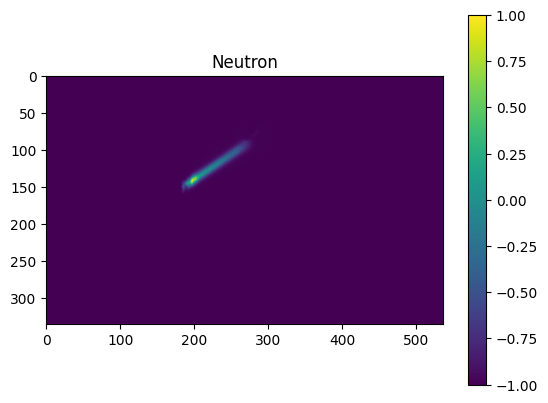

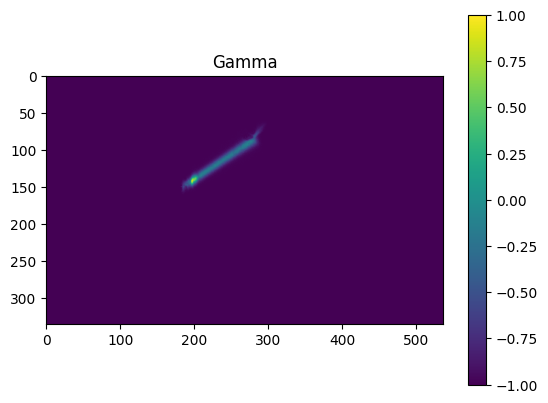

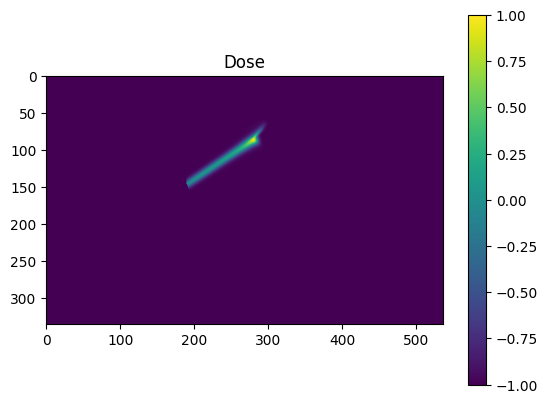

In [78]:
slice = 67

plt.figure()
plt.imshow(PG_FN_0[0, slice,:,:])
plt.title("Neutron")
plt.colorbar()
plt.show()
plt.figure()
plt.title("Gamma")
plt.imshow(PG_FN_0[1, slice,:,:])
plt.colorbar()
plt.show()
plt.figure()
plt.title("Dose")
plt.imshow(dose_0[0, slice,:,:])
plt.colorbar()
plt.show()

torch.Size([2, 109, 336, 537])
67
torch.Size([2, 109, 336, 537])
torch.Size([1, 20, 136, 181])


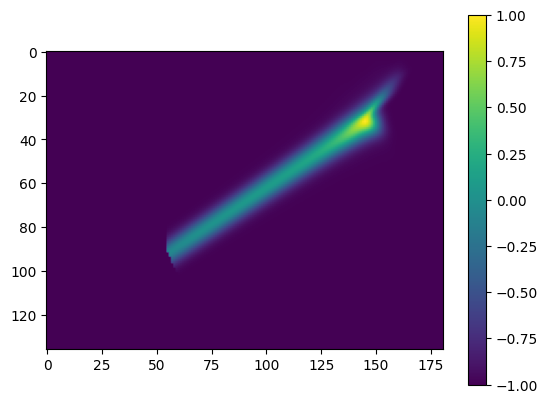

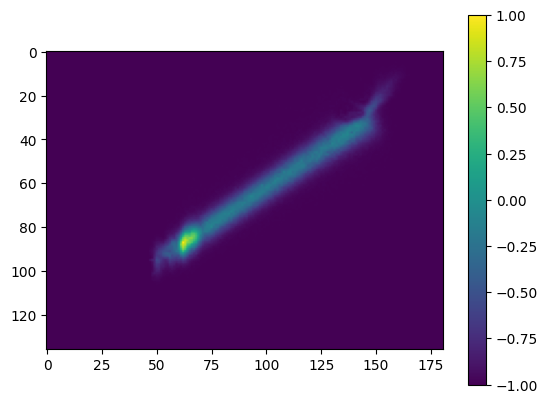

In [127]:

def find_margins(dose_2d):
    thres = threshold_otsu(dose_2d)
    binary_mask = dose_2d  > thres
    labels = label(binary_mask, connectivity = 2)
    props = regionprops(labels)

    largest_region = max(props, key = lambda r: r.area)

    #label_image = label(test_labelling)
    single_object_mask = labels == largest_region.label
    #print(single_object_mask)

    #Find x_first,x_last
    cols = np.where(single_object_mask.any(axis=0))[0]
    x_first, x_last = cols[0], cols[-1]

    rows = np.where(single_object_mask.any(axis=1))[0]
    y_first, y_last = rows[0], rows[-1]

    return x_first, x_last, y_first,y_last



def crop_tensors(dose,PG_FN, x_margin, y_margin, z_margin):
    index_highest_val = np.unravel_index(PG_FN[0].argmax(), PG_FN[0].shape)
    print(PG_FN.shape)
    slice = index_highest_val[0]
    print(slice)

    PG_FN_2d = np.array(PG_FN[0,slice,:,:])
    print(PG_FN.shape)

    x_first, x_last, y_first,y_last = find_margins(PG_FN_2d)

    dose_cropped = dose[:,slice-z_margin:slice+z_margin, y_first - y_margin:y_last + y_margin, x_first - x_margin: x_last + x_margin]
    PG_FN_cropped = PG_FN[:,slice-z_margin:slice+z_margin, y_first - y_margin:y_last + y_margin, x_first - x_margin: x_last + x_margin]

    return dose_cropped, PG_FN_cropped

# Check whether remove PG/FN outside patient is necessary. Should be quite easy

dose_cropped, PG_FN_cropped = crop_tensors(dose_0, PG_FN_0, x_margin = 50,y_margin = 40,z_margin=10)
print(dose_cropped.shape)

plt.imshow(dose_cropped[0,10])
plt.colorbar()
plt.show()
plt.imshow(PG_FN_cropped[1,10])
plt.colorbar()

### Test cropping

67


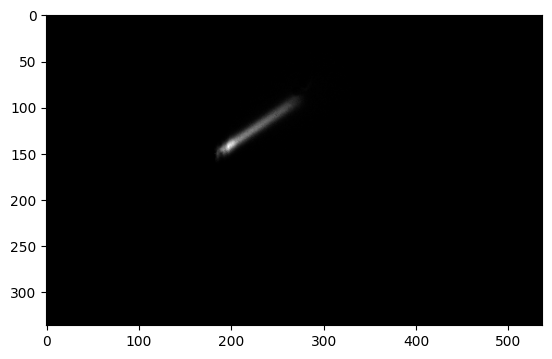

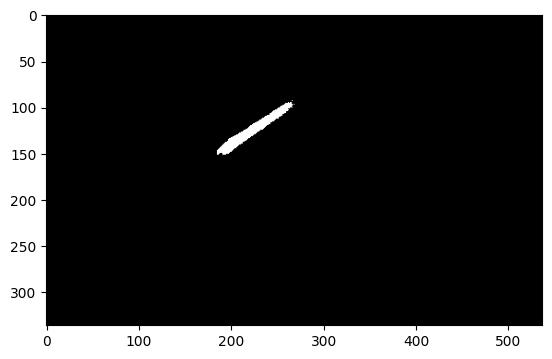

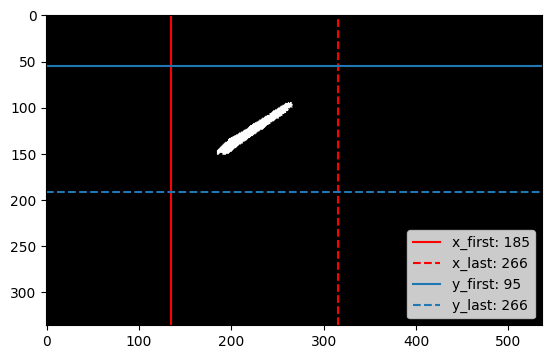

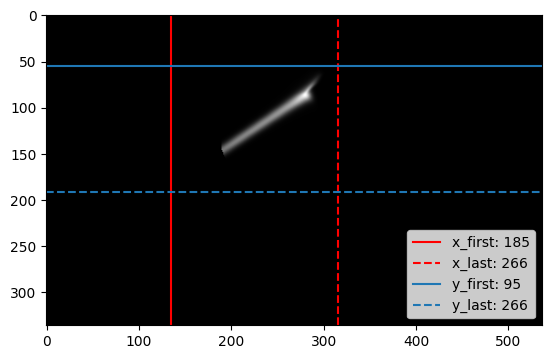

In [124]:
index_highest_val = np.unravel_index(PG_FN_0[0,:,:,:].argmax(), PG_FN_0[0,:,:,:].shape) 
slice = index_highest_val[0]
print(slice)

test_labelling = np.array(PG_FN_0[0,slice,:,:])
thres = threshold_otsu(test_labelling)
binary_mask = test_labelling > thres
labels = label(binary_mask, connectivity = 2)
props = regionprops(labels)



largest_region = max(props, key = lambda r: r.area)


#label_image = label(test_labelling)
single_object_mask = labels == largest_region.label
#print(single_object_mask)

#Find x_first,x_last
cols = np.where(single_object_mask.any(axis=0))[0]
x_first, x_last = cols[0], cols[-1]

rows = np.where(single_object_mask.any(axis=1))[0]
y_first, y_last = rows[0], rows[-1]

margin_x = 50
margin_y = 40
margin_z = 5


plt.imshow(test_labelling, cmap = "gray")
plt.show()
plt.imshow(binary_mask, cmap = "gray")
plt.show()
plt.imshow(single_object_mask, cmap= "gray")
plt.axvline(x_first - margin_x, color = "red", label = f"x_first: {x_first}")
plt.axvline(x_last + margin_x,color = "red",linestyle = "--",label = f"x_last: {x_last}")
plt.axhline(y_first - margin_y,label = f"y_first: {y_first}")
plt.axhline(y_last + margin_y,linestyle = "--",label = f"y_last: {x_last}")
plt.legend()
plt.show()

plt.imshow(dose_0[0,slice], cmap= "gray")
plt.axvline(x_first - margin_x, color = "red", label = f"x_first: {x_first}")
plt.axvline(x_last + margin_x,color = "red",linestyle = "--",label = f"x_last: {x_last}")
plt.axhline(y_first - margin_y,label = f"y_first: {y_first}")
plt.axhline(y_last + margin_y,linestyle = "--",label = f"y_last: {x_last}")
plt.legend()
plt.show()


67
5


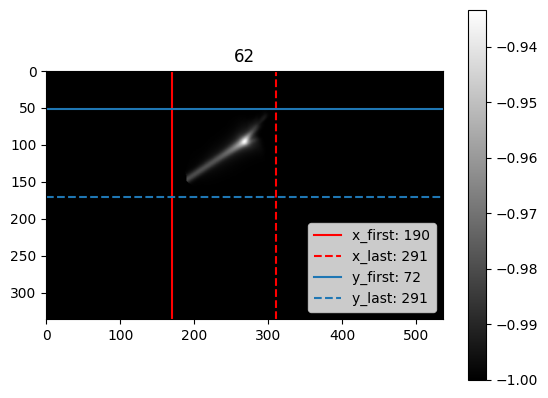

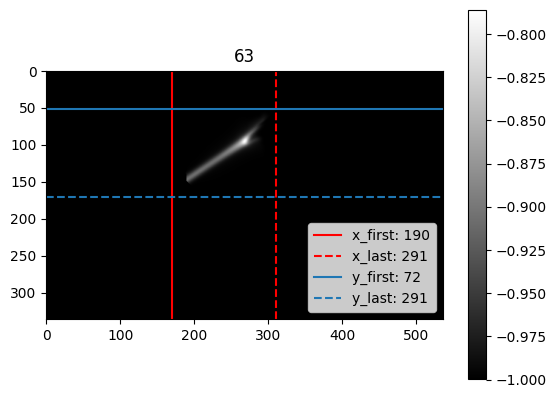

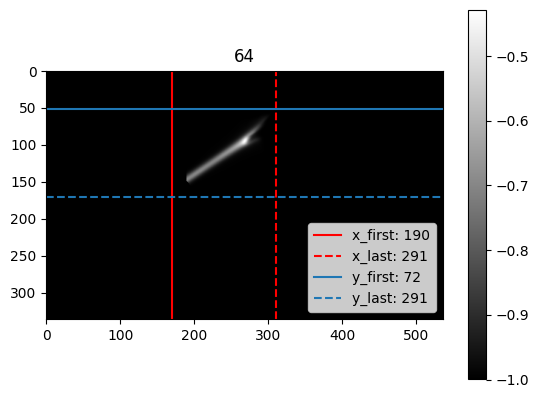

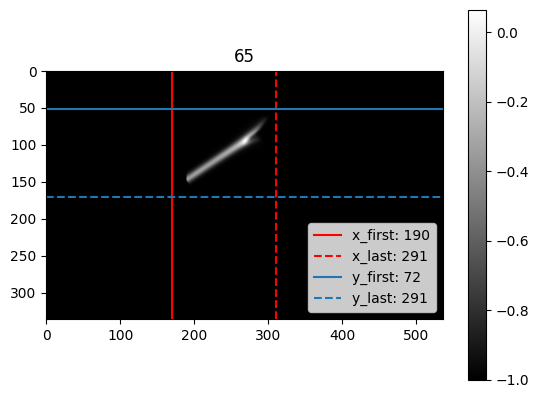

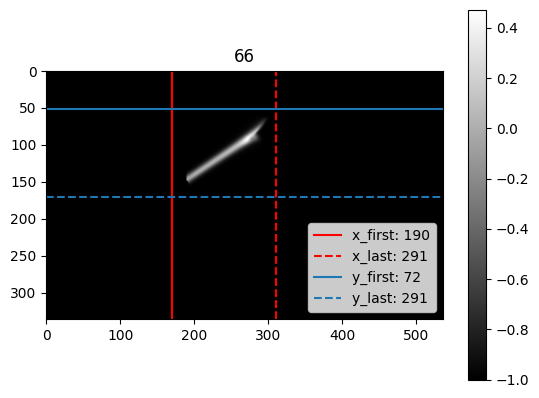

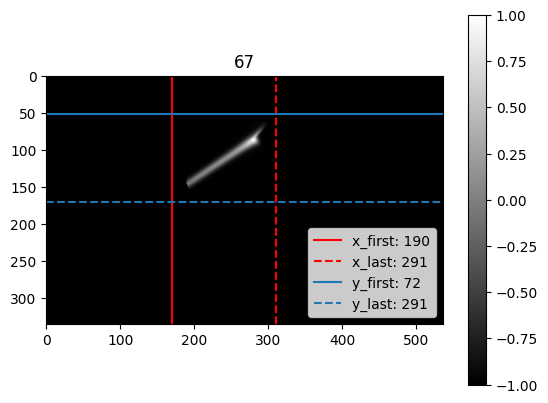

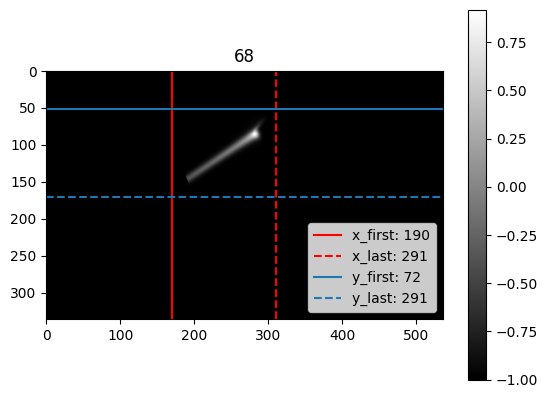

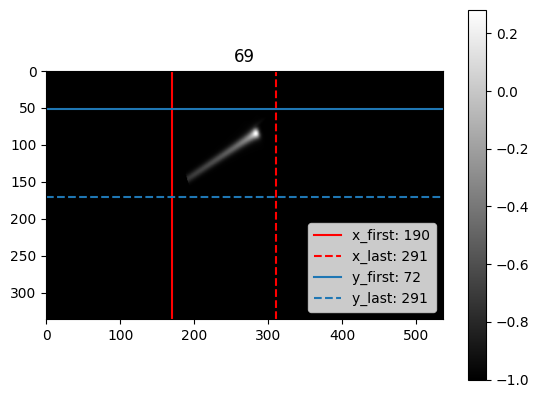

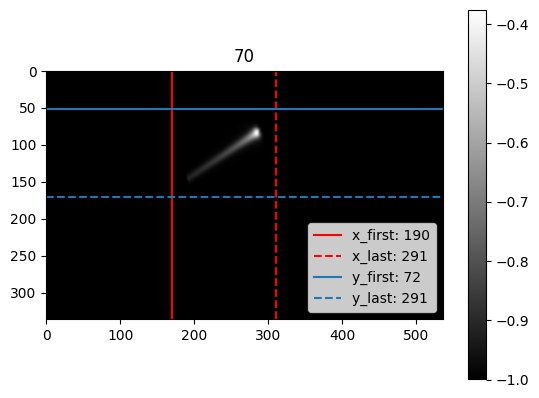

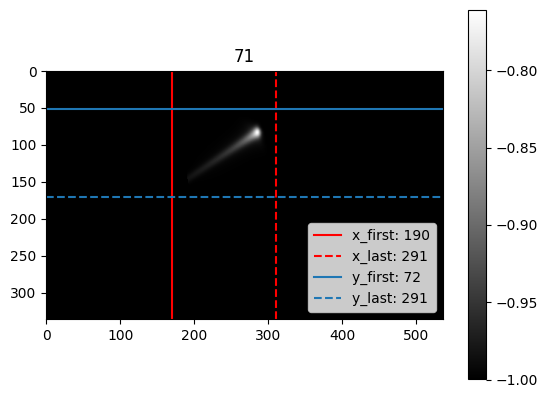

In [93]:
print(slice)
print(margin_z)
for i in range(slice - margin_z, slice + margin_z):
    image = np.array(dose_0[0,i,:,:])
    plt.imshow(image, cmap= "gray")
    plt.title(str(i))
    plt.axvline(x_first - margin_x, color = "red", label = f"x_first: {x_first}")
    plt.axvline(x_last + margin_x,color = "red",linestyle = "--",label = f"x_last: {x_last}")
    plt.axhline(y_first - margin_y,label = f"y_first: {y_first}")
    plt.axhline(y_last + margin_y,linestyle = "--",label = f"y_last: {x_last}")
    plt.legend()
    plt.colorbar()
    plt.show()


67
10


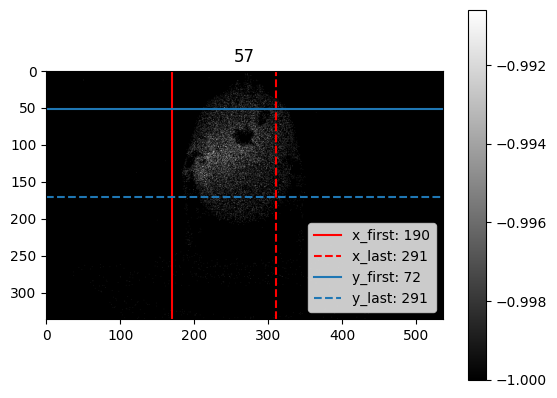

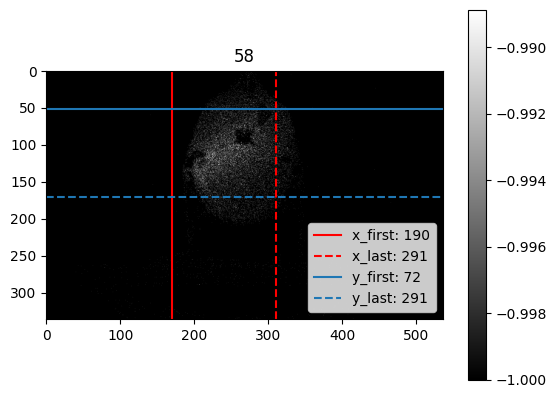

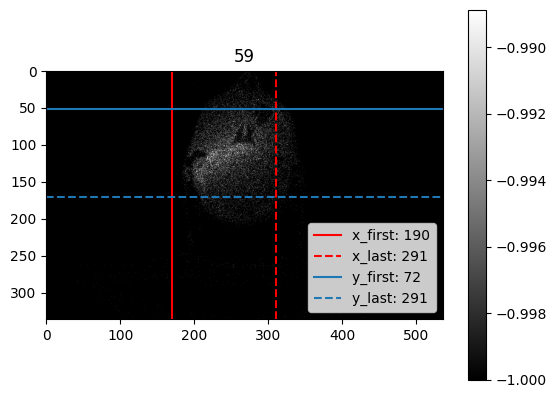

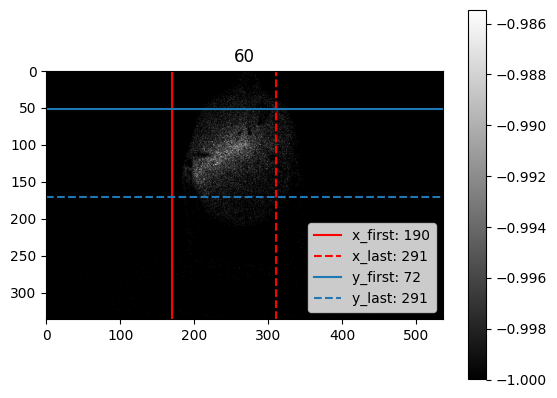

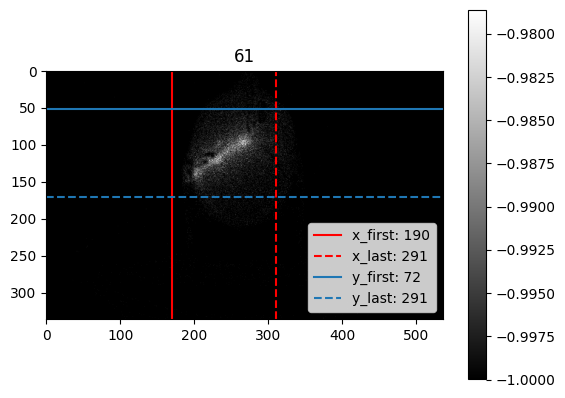

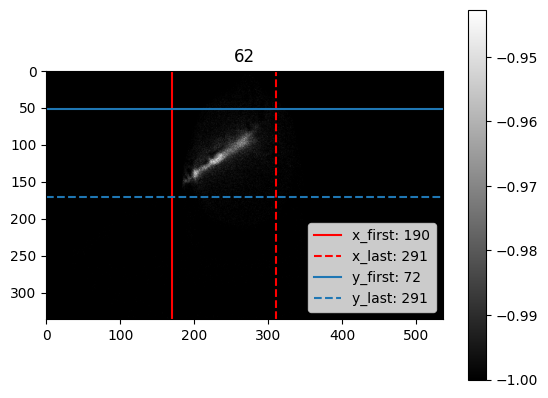

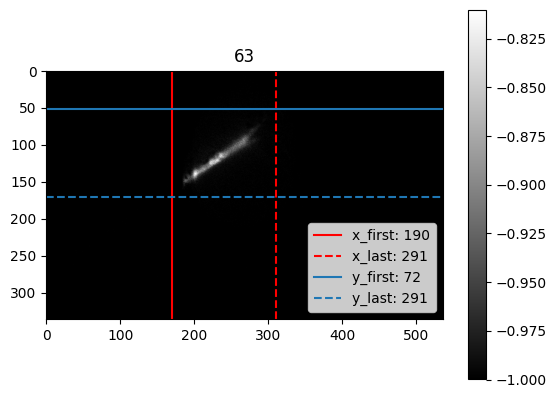

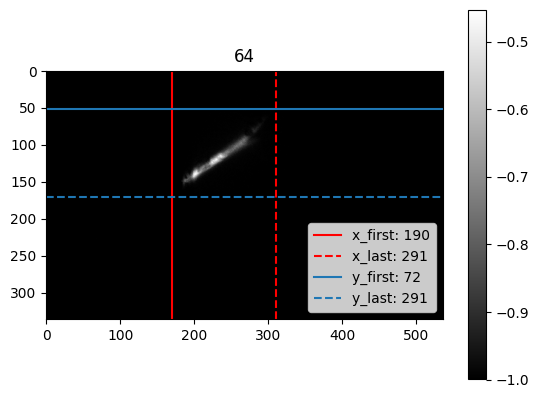

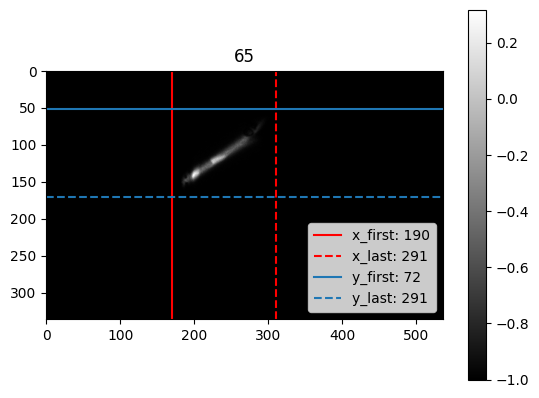

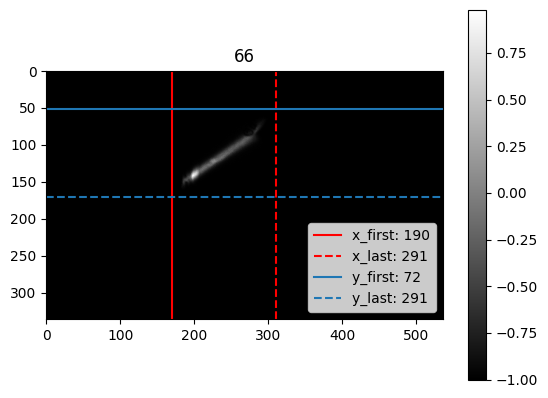

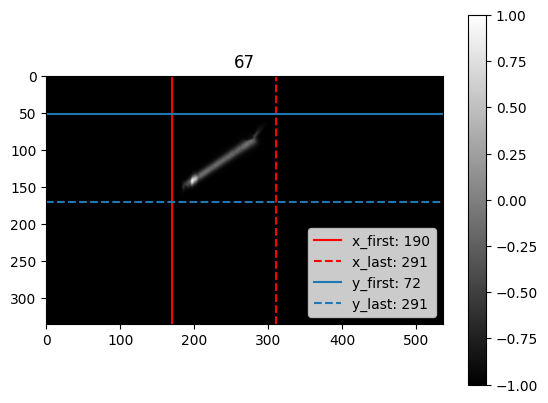

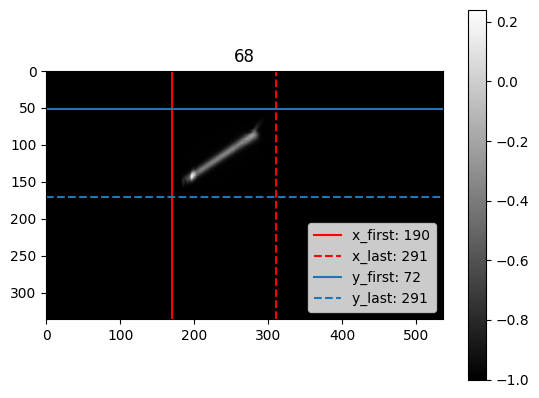

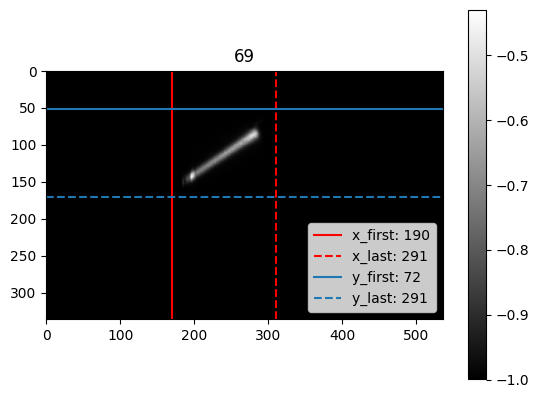

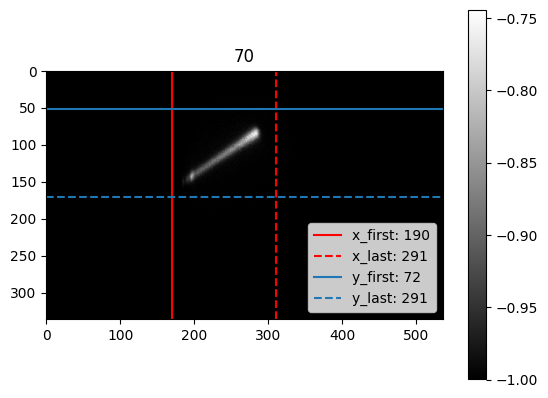

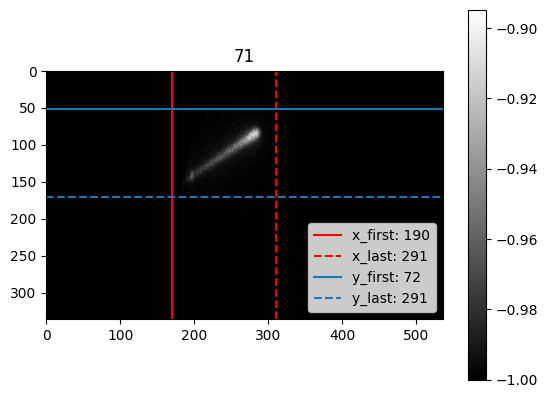

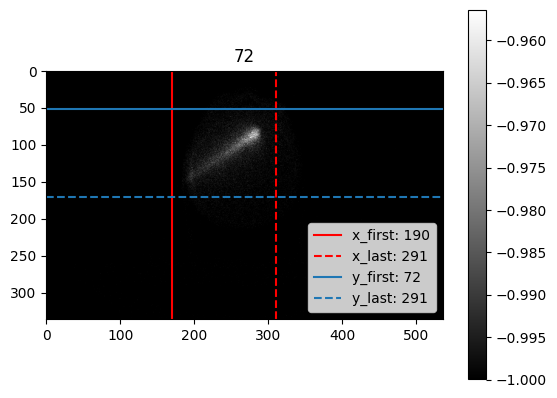

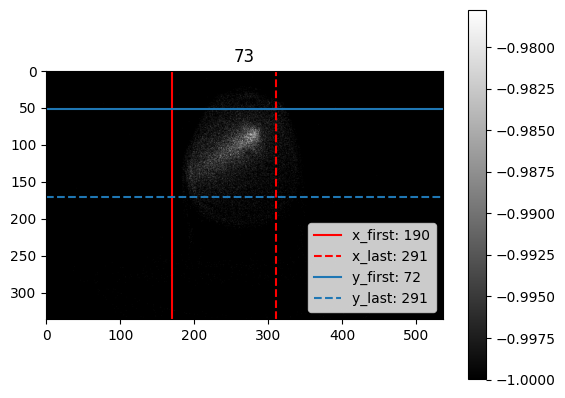

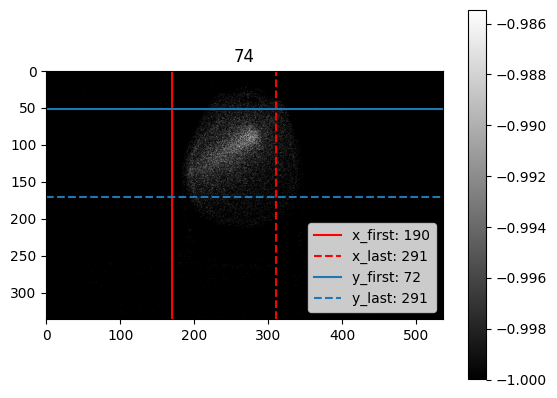

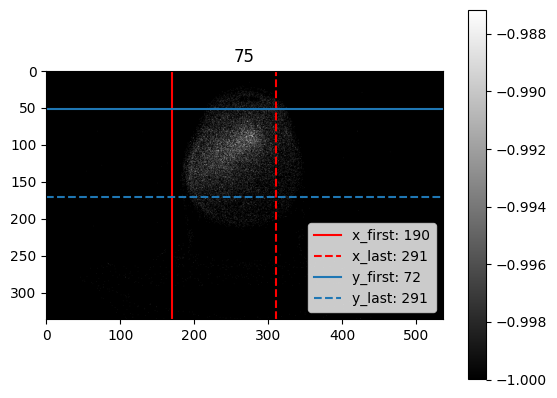

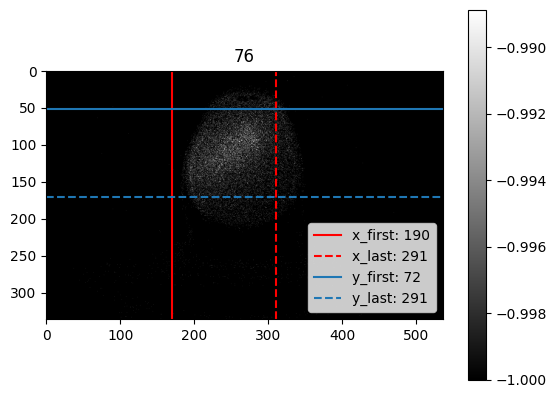

In [91]:
print(slice)
print(margin_z)
for i in range(slice - margin_z, slice + margin_z):
    image = np.array(PG_FN_0[1,i,:,:])
    plt.imshow(image, cmap= "gray")
    plt.title(str(i))
    plt.axvline(x_first - margin_x, color = "red", label = f"x_first: {x_first}")
    plt.axvline(x_last + margin_x,color = "red",linestyle = "--",label = f"x_last: {x_last}")
    plt.axhline(y_first - margin_y,label = f"y_first: {y_first}")
    plt.axhline(y_last + margin_y,linestyle = "--",label = f"y_last: {x_last}")
    plt.legend()
    plt.colorbar()
    plt.show()
